In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("/kaggle/input/datasets/paramvir705/netflix-dataset/netflix_titles.csv")

print(df.shape)
print('\n')
print(df.head())
print('\n')
print('\nColumns:',df.columns.tolist())
print('\n')
print('Types:\n', df.dtypes)
print('\n')
print('Info:\n', df.info())
print('Null:\n', df.isnull().sum())

(8807, 12)


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24,

In [15]:
# Cleaning the dataset
# fill nulls
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [16]:
# Drop small missing rows
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


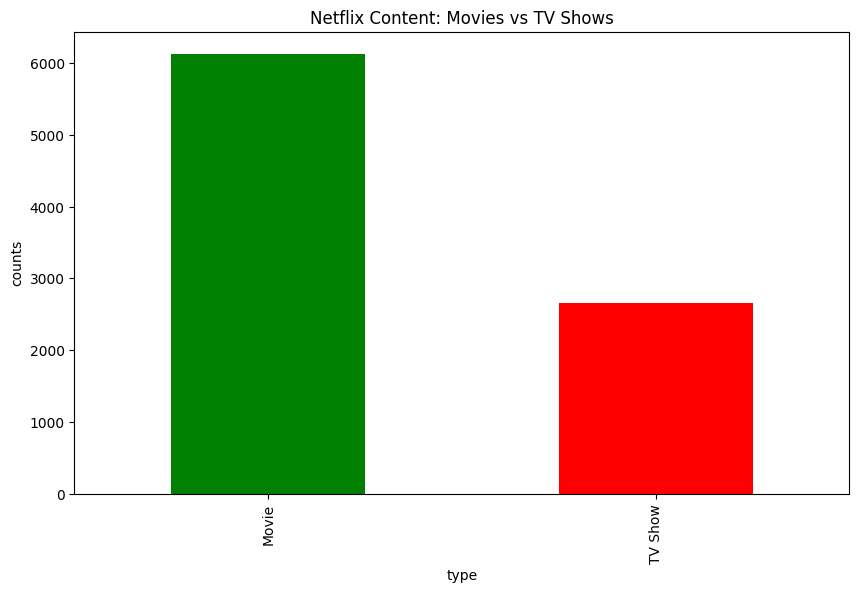

In [18]:
plt.figure(figsize=(10,6))
df['type'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.xlabel('type')
plt.ylabel('counts')
plt.title('Netflix Content: Movies vs TV Shows')
plt.show()

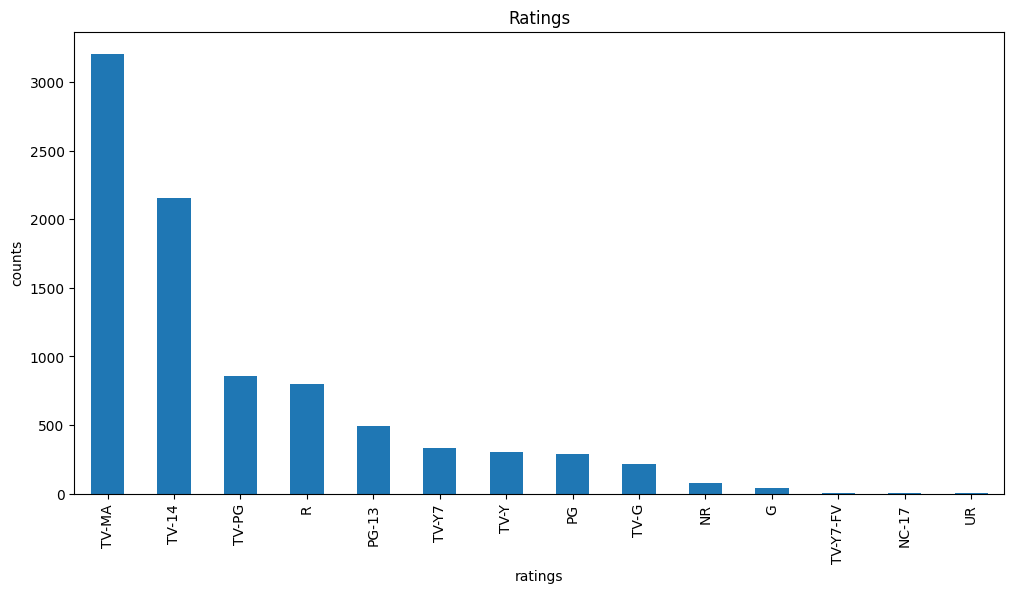

In [19]:
plt.figure(figsize=(12,6))
df['rating'].value_counts().plot(kind='bar')
plt.xlabel('ratings')
plt.ylabel('counts')
plt.title('Ratings')
plt.show()

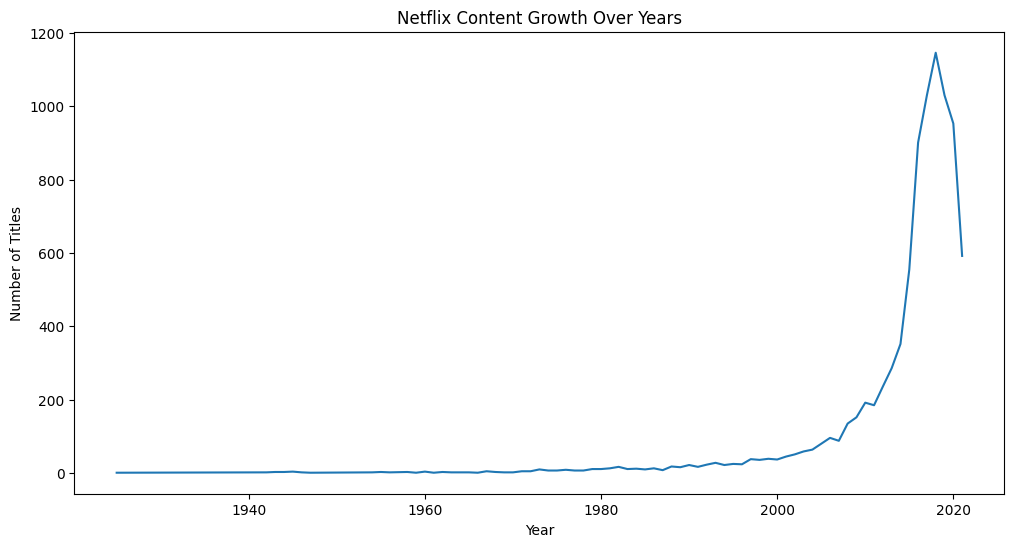

In [20]:
df['release_year'].value_counts().sort_index().plot(kind='line', figsize=(12,6))
plt.title('Netflix Content Growth Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

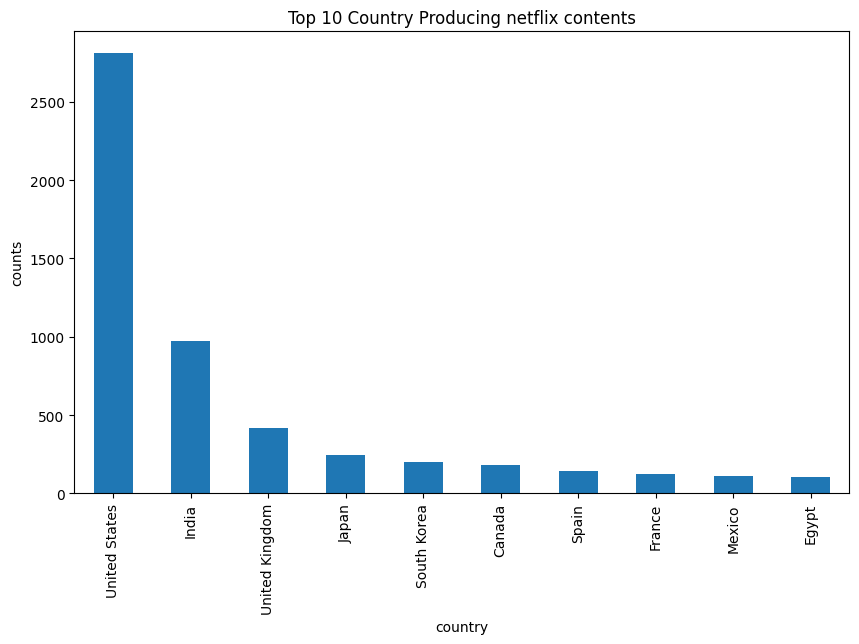

In [29]:
df[df['country'] != 'Unknown']['country'].value_counts().head(10).plot(kind='bar', figsize=(10,6))
plt.xlabel('country')
plt.ylabel('counts')
plt.title('Top 10 Country Producing netflix contents')
plt.show()

In [31]:
# Converting to date time
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

# Extracting month and year
df['month_added'] = df['date_added'].dt.month
df['year_added'] = df['date_added'].dt.year

print(df[['date_added', 'month_added', 'year_added']].head())

  date_added  month_added  year_added
0 2021-09-25            9        2021
1 2021-09-24            9        2021
2 2021-09-24            9        2021
3 2021-09-24            9        2021
4 2021-09-24            9        2021


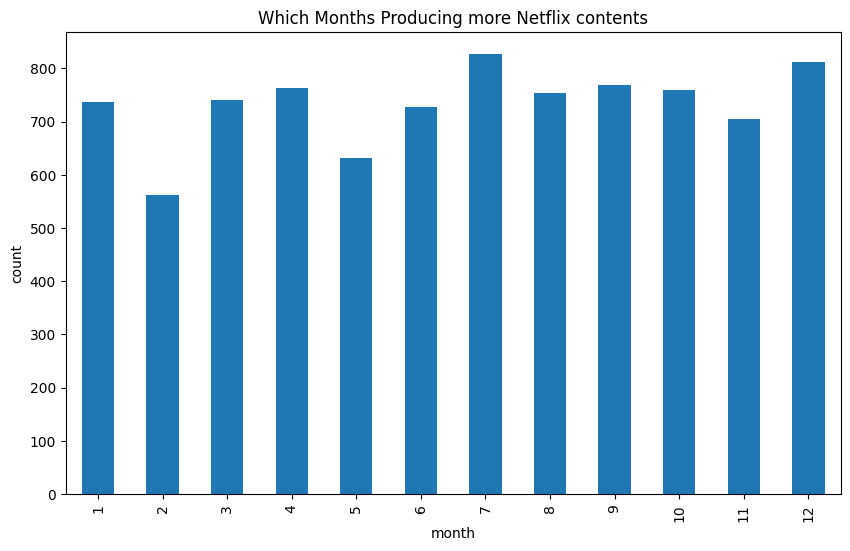

In [33]:
df['month_added'].value_counts().sort_index().plot(kind='bar', figsize=(10,6))
plt.xlabel('month')
plt.ylabel('count')
plt.title('Which Months Producing more Netflix contents')
plt.show()

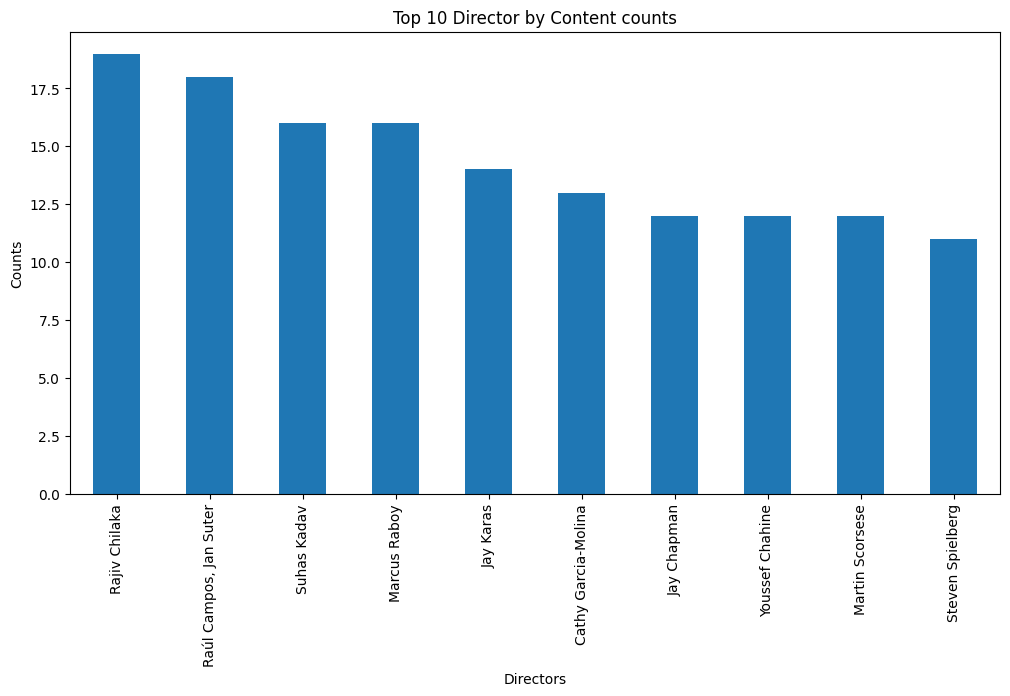

In [34]:
df[df['director']!='Unknown']['director'].value_counts().head(10).plot(kind='bar',figsize=(12,6))
plt.xlabel('Directors')
plt.ylabel('Counts')
plt.title('Top 10 Director by Content counts')
plt.show()